In [1]:
import scanpy as sc
import scvelo as scv
import pandas as pd
import numpy as np

In [2]:
adata_raw = sc.read_h5ad('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/data/scMulti-omics/1.hscAdata_raw.h5ad')
# previous label error 
adata_raw.obs['sample2'] = adata_raw.obs['Sample'].replace({
    'GW7': 'GW6',
    'GW6': 'GW7'
})
adata_raw.obs['barcode2'] = adata_raw.obs_names.str.rsplit('-', n=1).str[0]
adata_raw

AnnData object with n_obs × n_vars = 107558 × 36601
    obs: 'Sample', 'batch', 'sample2', 'barcode2'
    var: 'gene_ids', 'feature_types'

In [3]:
mat = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/Annotation/metadata_snRNA.csv', header=0, index_col=0)
mat.head()

,Sample,batch,sample2,barcode2,cluster,UMAP_1,UMAP_2,dataset,nUMI,nGene,...,Seurat_cell_type,barcode,cell_state,type,cell_name,cell_type,time,cell_type_major,cell_type_snRNA,major_type
AAACAGCCAGCAAGAT-1-0,GW7,0,GW6,AAACAGCCAGCAAGAT-1,6,1.980763,5.467843,rna_GW6,3658,2165,...,APC,AAACAGCCAGCAAGAT-1,GW6:APC,rna,APC/pMN,APC,GW6,AST,APC_ventral,APC_AST
AAACAGCCATAAAGCA-1-0,GW7,0,GW6,AAACAGCCATAAAGCA-1,22,2.296306,-8.415252,rna_GW6,3391,1933,...,multipotential_v,AAACAGCCATAAAGCA-1,GW6:multipotential_v,rna,multipotential_v,multipotential_v,GW6,v0/1,InN_ventral_2,InN
AAACAGCCATCGTTCT-1-0,GW7,0,GW6,AAACAGCCATCGTTCT-1,28,4.665377,5.040440,rna_GW6,6080,2889,...,NPC_pro_to_vIPC,AAACAGCCATCGTTCT-1,GW6:NPC_to_APC_OPC_p0/1_progenitor,rna,NPC_proliferative,NPC_pro_to_vIPC,GW6,NPC,NPC,NPC
AAACAGCCATTAGGTT-1-0,GW7,0,GW6,AAACAGCCATTAGGTT-1,35,8.468748,3.752999,rna_GW6,7095,3057,...,EC,AAACAGCCATTAGGTT-1,GW6:EC,rna,EC,EC,GW6,EC,Schwann,Schwann
AAACCAACAAAGCTCC-1-0,GW7,0,GW6,AAACCAACAAAGCTCC-1,38,6.415696,0.042469,rna_GW6,2830,1653,...,Micro,AAACCAACAAAGCTCC-1,GW6:Microglia,rna,Microglia,Micro,GW6,Micro,Microglia,Microglia


In [5]:
adata = adata_raw[adata_raw.obs.index.isin(mat.index), :].copy()
adata.obs.drop(columns=['Sample', 'batch', 'sample2', 'barcode2'], inplace=True)
adata.obs = adata.obs.join(mat)
adata.obsm['X_umap'] = adata.obs[['UMAP_1', 'UMAP_2']].values

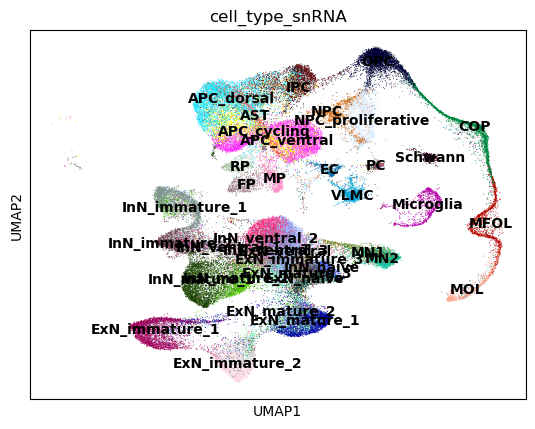

In [7]:
sc.pl.umap(
    adata,
    color=["cell_type_snRNA"],
    legend_loc="on data",
)

In [8]:
adata.obs

,Sample,batch,sample2,barcode2,cluster,UMAP_1,UMAP_2,dataset,nUMI,nGene,...,Seurat_cell_type,barcode,cell_state,type,cell_name,cell_type,time,cell_type_major,cell_type_snRNA,major_type
AAACAGCCAGCAAGAT-1-0,GW7,0,GW6,AAACAGCCAGCAAGAT-1,6,1.980763,5.467843,rna_GW6,3658,2165,...,APC,AAACAGCCAGCAAGAT-1,GW6:APC,rna,APC/pMN,APC,GW6,AST,APC_ventral,APC_AST
AAACAGCCATAAAGCA-1-0,GW7,0,GW6,AAACAGCCATAAAGCA-1,22,2.296306,-8.415252,rna_GW6,3391,1933,...,multipotential_v,AAACAGCCATAAAGCA-1,GW6:multipotential_v,rna,multipotential_v,multipotential_v,GW6,v0/1,InN_ventral_2,InN
AAACAGCCATCGTTCT-1-0,GW7,0,GW6,AAACAGCCATCGTTCT-1,28,4.665377,5.040440,rna_GW6,6080,2889,...,NPC_pro_to_vIPC,AAACAGCCATCGTTCT-1,GW6:NPC_to_APC_OPC_p0/1_progenitor,rna,NPC_proliferative,NPC_pro_to_vIPC,GW6,NPC,NPC,NPC
AAACAGCCATTAGGTT-1-0,GW7,0,GW6,AAACAGCCATTAGGTT-1,35,8.468748,3.752999,rna_GW6,7095,3057,...,EC,AAACAGCCATTAGGTT-1,GW6:EC,rna,EC,EC,GW6,EC,Schwann,Schwann
AAACCAACAAAGCTCC-1-0,GW7,0,GW6,AAACCAACAAAGCTCC-1,38,6.415696,0.042469,rna_GW6,2830,1653,...,Micro,AAACCAACAAAGCTCC-1,GW6:Microglia,rna,Microglia,Micro,GW6,Micro,Microglia,Microglia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTCACAAAT-1-7,GW20,7,GW20,TTTGTTGGTCACAAAT-1,9,4.518256,10.303347,rna_GW20,2709,1572,...,OPC,TTTGTTGGTCACAAAT-1,GW20:OPC,rna,OPC,OPC,GW20,OL,OPC,OPC_OL
TTTGTTGGTTACTAGG-1-7,GW20,7,GW20,TTTGTTGGTTACTAGG-1,4,-3.577783,7.019143,rna_GW20,1826,1164,...,AST_dorsal_PA,TTTGTTGGTTACTAGG-1,GW20:AST_dorsal_PA,rna,dp3-6_switched?,dp3-6_switched,GW20,AST,APC_dorsal,APC_AST
TTTGTTGGTTAGGACC-1-7,GW20,7,GW20,TTTGTTGGTTAGGACC-1,39,4.521836,4.780902,rna_GW20,2818,1632,...,OPC_pro,TTTGTTGGTTAGGACC-1,GW20:OPC_pro,rna,OPC_proliferative,OPC_pro,GW20,OL,NPC_proliferative,NPC
TTTGTTGGTTGCACAA-1-7,GW20,7,GW20,TTTGTTGGTTGCACAA-1,5,-2.883862,4.253162,rna_GW20,3318,1784,...,AST_ventral_PA,TTTGTTGGTTGCACAA-1,GW20:AST_ventral_PA,rna,APC-3,APC,GW20,AST,APC_ventral,APC_AST


In [9]:
adata.obs[['barcode2', 'sample2', 'cell_type_snRNA']].to_csv('hsc_lineage.csv')